In [1]:
!gdown 1v8NUJvQyvSYu5AzmsuMYwI6n92MlhhaF

Downloading...
From (original): https://drive.google.com/uc?id=1v8NUJvQyvSYu5AzmsuMYwI6n92MlhhaF
From (redirected): https://drive.google.com/uc?id=1v8NUJvQyvSYu5AzmsuMYwI6n92MlhhaF&confirm=t&uuid=59817ef3-4023-45a4-9cf1-d5025dcf6351
To: /content/Csv\ai_human_final.csv
100% 426M/426M [00:06<00:00, 61.4MB/s]


In [6]:
!ls -la

total 415728
drwxr-xr-x 1 root root      4096 Jan 13 21:46  .
drwxr-xr-x 1 root root      4096 Jan 13 21:43  ..
drwxr-xr-x 4 root root      4096 Dec  9 14:41  .config
-rw-r--r-- 1 root root 425681562 Jan 13 21:42 'Csv\ai_human_final.csv'
drwxr-xr-x 1 root root      4096 Dec  9 14:42  sample_data


In [24]:
import numpy as np
import pandas as pd

import torch
from torch import nn
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset

import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
datadf = pd.read_csv("/content/ai_human_final.csv")

In [8]:
datadf.head(5)


,Unnamed: 0,text,generated
0,0,Cars. Cars have been around since they became ...,0.0
1,1,Transportation is a large necessity in most co...,0.0
2,2,"""America's love affair with it's vehicles seem...",0.0
3,3,How often do you ride in a car? Do you drive a...,0.0
4,4,Cars are a wonderful thing. They are perhaps o...,0.0


In [9]:
def dataframe_tolist(df):
  TexT = df['text'].tolist()
  label = df['generated'].tolist()

  return TexT , label

In [10]:
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

In [11]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=256):
        self.texts = texts  # Store only references, not processed data
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        # Process ONE sample at a time (no memory overload)
        text = str(self.texts[idx])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [12]:
text , labels = dataframe_tolist(datadf)

In [13]:
train_texts, val_texts, train_labels, val_labels = train_test_split(
    text, labels, test_size=0.15, random_state=42, stratify=labels)

In [14]:
len(train_texts)

248950

In [15]:
train_dataset = TextDataset(train_texts, train_labels, tokenizer)


In [16]:
val_dataset = TextDataset(val_texts, val_labels, tokenizer)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,  # Adjust based on your RAM
    shuffle=True,
    num_workers=2  # Parallel loading
)


In [18]:
val_loader = DataLoader(
    val_dataset,
    batch_size=8,  # Adjust based on your RAM
    shuffle=True,
    num_workers=2  # Parallel loading
)

In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=128,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=50,
    save_strategy= 'steps',
    save_steps=2500,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    disable_tqdm= False,
    eval_strategy='steps',
    eval_steps=2500,
    fp16=True,
    optim="adamw_torch",
    dataloader_num_workers=4,
)

In [19]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.11,
    logging_dir='./logs',
    logging_steps=50,
    save_strategy='steps',
    save_steps=2500,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',  # You can change this to 'eval_accuracy'
    disable_tqdm=False,
    eval_strategy='steps',
    eval_steps=2500,
    fp16=True,
    optim="adamw_torch",
    dataloader_num_workers=2,  # ← Change from 4 to 2 to fix the warning
    dataloader_pin_memory=False,  # ← Add this to reduce memory usage
)

In [20]:
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2,  hidden_dropout_prob=0.1,  # Add dropout
    attention_probs_dropout_prob=0.1,classifier_dropout=0.1)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
# 6. Create trainer and train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

In [22]:
# Start training
trainer.train()

# 7. Save the model
model.save_pretrained('./my_roberta_model')
tokenizer.save_pretrained('./my_roberta_model')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: beshoyashraf042 (beshoyashraf042-it) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss
2500,0.074400,0.111133
5000,0.063400,0.083272
7500,0.054100,0.108220
10000,0.048900,0.076826
12500,0.036800,0.119290
15000,0.039200,0.097439


('./my_roberta_model/tokenizer_config.json',
 './my_roberta_model/special_tokens_map.json',
 './my_roberta_model/vocab.json',
 './my_roberta_model/merges.txt',
 './my_roberta_model/added_tokens.json',
 './my_roberta_model/tokenizer.json')

In [25]:
# Use trainer for predictions
predictions_output = trainer.predict(val_dataset)

# Get predictions and labels
predictions = np.argmax(predictions_output.predictions, axis=-1)
true_labels = predictions_output.label_ids

# Then calculate metrics as shown above
conf_matrix = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:")
print(conf_matrix)
print()

print("Classification Report:")
print(classification_report(true_labels, predictions, target_names=['Class 0', 'Class 1']))

Confusion Matrix:
[[22271   732]
 [  228 20702]]

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.97      0.98     23003
     Class 1       0.97      0.99      0.98     20930

    accuracy                           0.98     43933
   macro avg       0.98      0.98      0.98     43933
weighted avg       0.98      0.98      0.98     43933



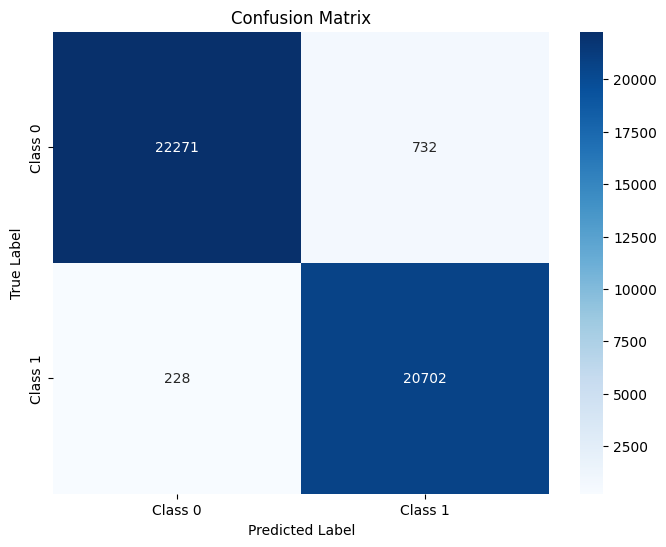

In [26]:
# Visualize confusion matrix
def plot_confusion_matrix(conf_matrix, class_names):
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(conf_matrix, ['Class 0', 'Class 1'])

In [27]:
!zip -r my_roberta_model_ai_human.zip my_roberta_model/

  adding: my_roberta_model/ (stored 0%)
  adding: my_roberta_model/tokenizer_config.json (deflated 75%)
  adding: my_roberta_model/model.safetensors (deflated 8%)
  adding: my_roberta_model/special_tokens_map.json (deflated 52%)
  adding: my_roberta_model/config.json (deflated 51%)
  adding: my_roberta_model/tokenizer.json (deflated 82%)
  adding: my_roberta_model/vocab.json (deflated 59%)
  adding: my_roberta_model/merges.txt (deflated 53%)


In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
!cp my_roberta_model_ai_human.zip "/content/drive/My Drive/models"